In [72]:
import numpy as np
import pandas as pd
df=pd.read_csv('LoanApprovalPrediction (1).csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [73]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [74]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents           float64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [75]:
df.describe

<bound method NDFrame.describe of       Loan_ID  Gender Married  Dependents     Education Self_Employed  \
0    LP001002    Male      No         0.0      Graduate            No   
1    LP001003    Male     Yes         1.0      Graduate            No   
2    LP001005    Male     Yes         0.0      Graduate           Yes   
3    LP001006    Male     Yes         0.0  Not Graduate            No   
4    LP001008    Male      No         0.0      Graduate            No   
..        ...     ...     ...         ...           ...           ...   
593  LP002978  Female      No         0.0      Graduate            No   
594  LP002979    Male     Yes         3.0      Graduate            No   
595  LP002983    Male     Yes         1.0      Graduate            No   
596  LP002984    Male     Yes         2.0      Graduate            No   
597  LP002990  Female      No         0.0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               

In [76]:
df.drop('Loan_ID',axis=1,inplace=True)

In [77]:
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)

In [78]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)


In [79]:
df.isna().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [80]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


In [81]:
df.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [82]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,127.0,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
593,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
596,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [83]:
from sklearn.preprocessing import LabelEncoder
label_encoders={}
categorical_cols=['Gender','Married','Education','Self_Employed','Property_Area']
for col in categorical_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
    label_encoders[col]=le

In [84]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,127.0,360.0,1.0,2,Y
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,N
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,Y
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,Y
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,0,0.0,0,0,2900,0.0,71.0,360.0,1.0,0,Y
594,1,1,3.0,0,0,4106,0.0,40.0,180.0,1.0,0,Y
595,1,1,1.0,0,0,8072,240.0,253.0,360.0,1.0,2,Y
596,1,1,2.0,0,0,7583,0.0,187.0,360.0,1.0,2,Y


In [85]:
from sklearn.model_selection import train_test_split
x=df.drop(columns='Loan_Status')
y=df['Loan_Status']
print(x)
print(x.ndim)

     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0         0.0          0              0             5849   
1         1        1         1.0          0              0             4583   
2         1        1         0.0          0              1             3000   
3         1        1         0.0          1              0             2583   
4         1        0         0.0          0              0             6000   
..      ...      ...         ...        ...            ...              ...   
593       0        0         0.0          0              0             2900   
594       1        1         3.0          0              0             4106   
595       1        1         1.0          0              0             8072   
596       1        1         2.0          0              0             7583   
597       0        0         0.0          0              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Ter

In [86]:
print(y)
print(y.ndim)

0      Y
1      N
2      Y
3      Y
4      Y
      ..
593    Y
594    Y
595    Y
596    Y
597    N
Name: Loan_Status, Length: 598, dtype: object
1


In [87]:
from sklearn.utils import resample
df_majority=df[df.Loan_Status=='Y']
len(df_majority)

411

In [88]:
df_minority=df[df.Loan_Status=='N']
len(df_minority)

187

In [89]:
df_majority_downsampled=resample(df_majority,
                                 replace=False,
                                 n_samples=len(df_minority),
                                 random_state=42)
df_balanced=pd.concat([df_majority_downsampled,df_minority])

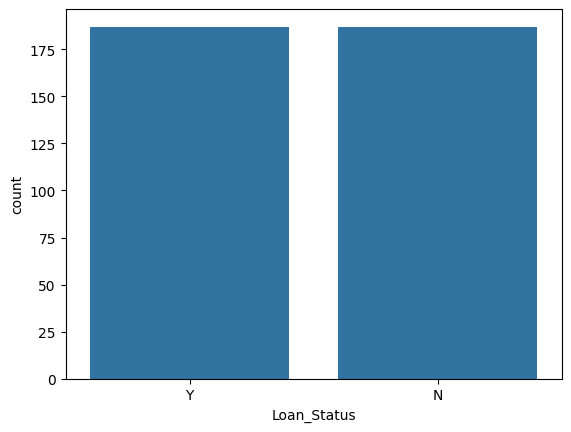

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Loan_Status',data=df_balanced)
plt.show()

In [91]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [92]:
from sklearn.tree import DecisionTreeClassifier
d_tree=DecisionTreeClassifier(random_state=42,criterion='entropy')
d_tree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [93]:
y_pred=d_tree.predict(x_test)

In [94]:
from sklearn.metrics import accuracy_score,classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7055555555555556


In [95]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       0.49      0.50      0.50        52
           Y       0.80      0.79      0.79       128

    accuracy                           0.71       180
   macro avg       0.64      0.64      0.64       180
weighted avg       0.71      0.71      0.71       180



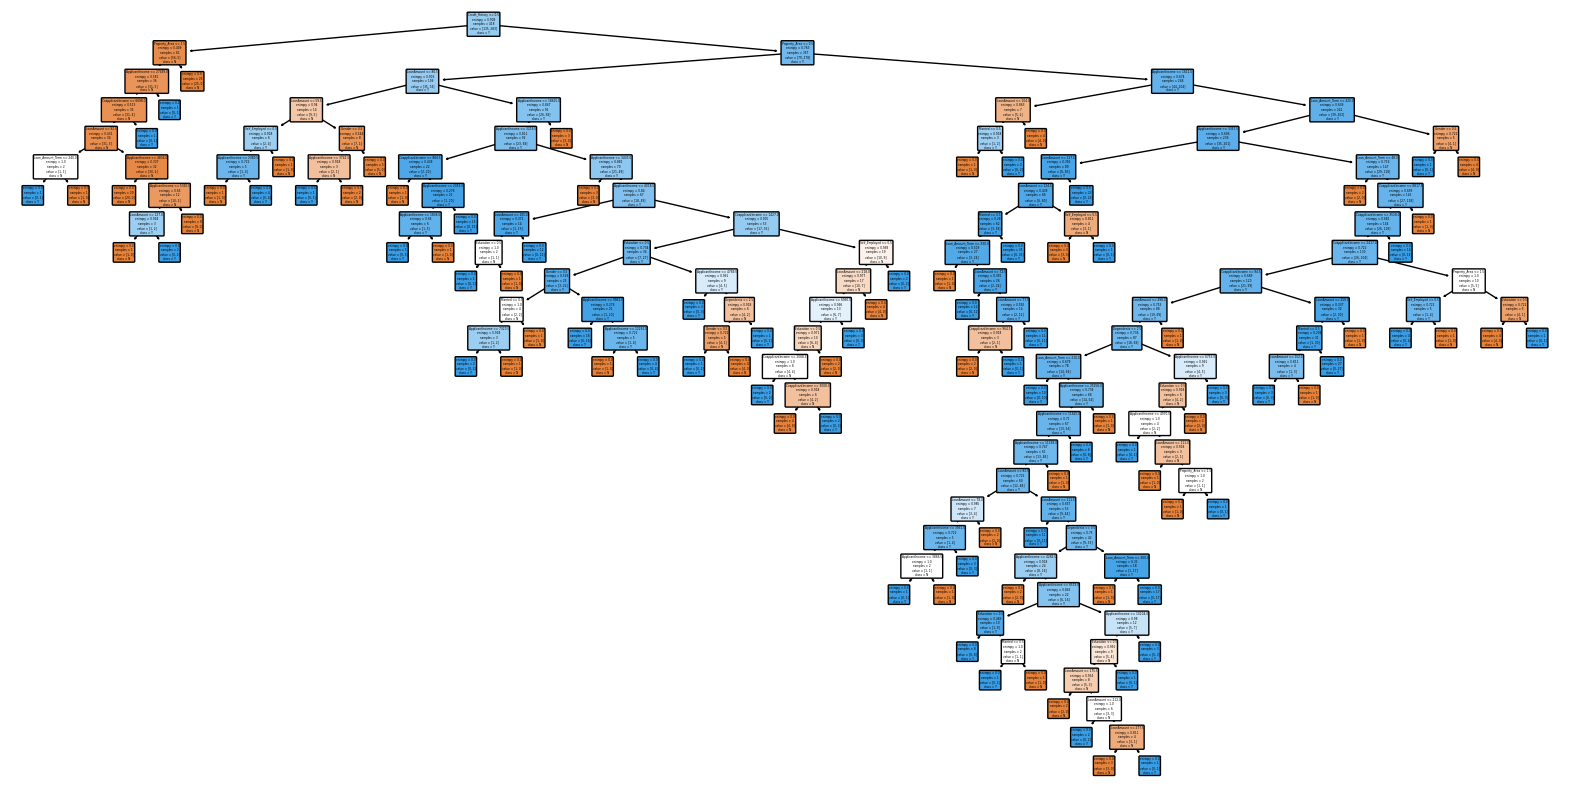

In [96]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(d_tree,
          feature_names=x.columns,
          class_names=['N','Y'],
          filled=True,
          rounded=True)
plt.show()

In [97]:
import joblib
joblib.dump(d_tree,'dtree_model.pkl')
joblib.dump(label_encoders,'label_encoder.pkl')

['label_encoder.pkl']

In [98]:
loaded_model=joblib.load('dtree_model.pkl')
loaded_encoders=joblib.load('label_encoder.pkl')

In [99]:
sample_data=x_test.iloc[[0]]
prediction=loaded_model.predict(sample_data)

print('Sample data for Prediction')
print(sample_data)
print('\npredicte Label : ',prediction)

Sample data for Prediction
     Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
127       1        0         0.0          0              1            20166   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
127                0.0       650.0             480.0             1.0   

     Property_Area  
127              2  

predicte Label :  ['N']


In [102]:
y_pred1=loaded_model.predict(x_test)
y_pred1

array(['N', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y',
       'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'N', 'Y', 'N', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'Y', 'N',
       'Y', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'N', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N', 'Y'],
 

In [103]:
from sklearn.metrics import accuracy_score,classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           N       0.49      0.50      0.50        52
           Y       0.80      0.79      0.79       128

    accuracy                           0.71       180
   macro avg       0.64      0.64      0.64       180
weighted avg       0.71      0.71      0.71       180



In [104]:
print(accuracy_score(y_test, y_pred))

0.7055555555555556
